# EDA Completo — PetFinder Adoption Prediction

**Dataset:** PetFinder Malaysia (Kaggle)  
**Objetivo:** Análisis exploratorio exhaustivo del dataset de adopción de mascotas para entender los factores que influyen en la velocidad de adopción (`AdoptionSpeed`).

---

##  Setup y Carga de Datos

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import json
import warnings
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Paleta consistente para AdoptionSpeed
SPEED_COLORS = {0: '#2ecc71', 1: '#27ae60', 2: '#f39c12', 3: '#e67e22', 4: '#e74c3c'}
SPEED_LABELS = {0: '0-Mismo día', 1: '1-1ª semana', 2: '2-1er mes', 3: '3-2-3 meses', 4: '4-Sin adopción'}
SPEED_PALETTE = [SPEED_COLORS[i] for i in sorted(SPEED_COLORS)]

BASE_PATH = '../input/petfinder-adoption-prediction'
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


In [91]:
#  Carga de datasets principales 
#Datos Tabulares
train = pd.read_csv(f'{BASE_PATH}/train/train.csv')
#Otros archivos:
# breed_labels.csv - Contains Type, and BreedName for each BreedID. Type 1 is dog, 2 is cat.
# color_labels.csv - Contains ColorName for each ColorID
# state_labels.csv - Contains StateName for each StateID

breed_labels = pd.read_csv(f'{BASE_PATH}/breed_labels.csv')
color_labels = pd.read_csv(f'{BASE_PATH}/color_labels.csv')
state_labels = pd.read_csv(f'{BASE_PATH}/state_labels.csv')

print(f'Train shape: {train.shape}')
print(f'Breed labels: {breed_labels.shape}')
print(f'Color labels: {color_labels.shape}')
print(f'State labels: {state_labels.shape}')

Train shape: (14993, 24)
Breed labels: (307, 3)
Color labels: (7, 2)
State labels: (15, 2)


In [92]:
# Decodificaciones de codigos a texto legible y features derivadas para el EDA 

# Tipo de animal
train['Type_name'] = train['Type'].map({1: 'Perro', 2: 'Gato'})

# Razas
breed_map = breed_labels.set_index('BreedID')['BreedName'].to_dict()
train['Breed1_name'] = train['Breed1'].map(breed_map).fillna('Desconocida')

# Colores
color_map = color_labels.set_index('ColorID')['ColorName'].to_dict()
train['Color1_name'] = train['Color1'].map(color_map).fillna('Desconocido')

# Estados
state_map = state_labels.set_index('StateID')['StateName'].to_dict()
train['State_name'] = train['State'].map(state_map).fillna('Desconocido')

# Género
train['Gender_name'] = train['Gender'].map({1: 'Macho', 2: 'Hembra', 3: 'Mixto'})

# Vacunación / Desparasitación / Esterilización
ynu_map = {1: 'Sí', 2: 'No', 3: 'No sabe'}
train['Vaccinated_name'] = train['Vaccinated'].map(ynu_map)
train['Dewormed_name']   = train['Dewormed'].map(ynu_map)
train['Sterilized_name'] = train['Sterilized'].map(ynu_map)

# Salud
train['Health_name']       = train['Health'].map({1: 'Saludable', 2: 'Lesión menor', 3: 'Lesión grave'})
train['MaturitySize_name'] = train['MaturitySize'].map({1: 'Pequeño', 2: 'Mediano', 3: 'Grande', 4: 'Extra grande', 0: 'No aplica'})
train['FurLength_name']    = train['FurLength'].map({1: 'Corto', 2: 'Mediano', 3: 'Largo', 0: 'No aplica'})

# ── Features derivadas ────────────────────────────────────────────────
train['Tiene_nombre'] = train['Name'].apply(
    lambda x: False if (pd.isna(x) or str(x).strip().lower() in ['no name', 'no name yet']) else True
)
train['Desc_len_words'] = train['Description'].fillna('').apply(lambda x: len(str(x).split()))
train['PhotoAmt']       = train['PhotoAmt'].astype(int)

# Grupos de fotos
def photo_group(n):
    if n == 0:    return '0 fotos'
    elif n <= 3:  return '1-3'
    elif n <= 7:  return '4-7'
    else:         return '8+'
train['photo_group'] = train['PhotoAmt'].apply(photo_group)

# Health score
train['health_score'] = (
    (train['Vaccinated'] == 1).astype(int) +
    (train['Dewormed']   == 1).astype(int) +
    (train['Sterilized'] == 1).astype(int) +
    (train['Health']     == 1).astype(int)
)

# Etiqueta legible para AdoptionSpeed
train['Speed_label'] = train['AdoptionSpeed'].map(SPEED_LABELS)

print('Decodificaciones y features derivadas creadas correctamente.')

Decodificaciones y features derivadas creadas correctamente.


In [93]:
# Vista general del dataset con las nuevas variables:
print(f'Shape: {train.shape}')
print(f'\nDTypes:')
print(train.dtypes)
train.head(3)

Shape: (14993, 40)

DTypes:
Type                  int64
Name                 object
Age                   int64
Breed1                int64
Breed2                int64
Gender                int64
Color1                int64
Color2                int64
Color3                int64
MaturitySize          int64
FurLength             int64
Vaccinated            int64
Dewormed              int64
Sterilized            int64
Health                int64
Quantity              int64
Fee                   int64
State                 int64
RescuerID            object
VideoAmt              int64
Description          object
PetID                object
PhotoAmt              int32
AdoptionSpeed         int64
Type_name            object
Breed1_name          object
Color1_name          object
State_name           object
Gender_name          object
Vaccinated_name      object
Dewormed_name        object
Sterilized_name      object
Health_name          object
MaturitySize_name    object
FurLength_name      

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Dewormed_name,Sterilized_name,Health_name,MaturitySize_name,FurLength_name,Tiene_nombre,Desc_len_words,photo_group,health_score,Speed_label
0,2,Nibble,3,299,0,1,1,7,0,1,...,No,No,Saludable,Pequeño,Corto,True,69,1-3,1,2-1er mes
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,No sabe,No sabe,Saludable,Mediano,Mediano,False,23,1-3,1,0-Mismo día
2,1,Brisco,1,307,0,1,2,7,0,2,...,Sí,No,Saludable,Mediano,Mediano,True,69,4-7,3,3-2-3 meses


---
##  Calidad de Datos

In [94]:
# Tabla resumen de calidad para verificar cardinalidad y nulos
original_cols = [c for c in train.columns if '_name' not in c and c not in
                 ['Speed_label','Tiene_nombre','Desc_len_words','photo_group','health_score']]
null_cols = [c for c in original_cols if train[c].isnull().any()]

summary = pd.DataFrame({
    'Columna'     : original_cols,
    'Tipo'        : [train[c].dtype for c in original_cols],
    '% Nulos'     : [(train[c].isnull().mean() * 100).round(2) for c in original_cols],
    'Cardinalidad': [train[c].nunique() for c in original_cols],
})
summary.sort_values('% Nulos', ascending=False)

,Columna,Tipo,% Nulos,Cardinalidad
1,Name,object,8.44,9059
20,Description,object,0.09,14031
0,Type,int64,0.00,2
22,PhotoAmt,int32,0.00,31
21,PetID,object,0.00,14993
19,VideoAmt,int64,0.00,9
18,RescuerID,object,0.00,5595
17,State,int64,0.00,14
16,Fee,int64,0.00,74
15,Quantity,int64,0.00,19


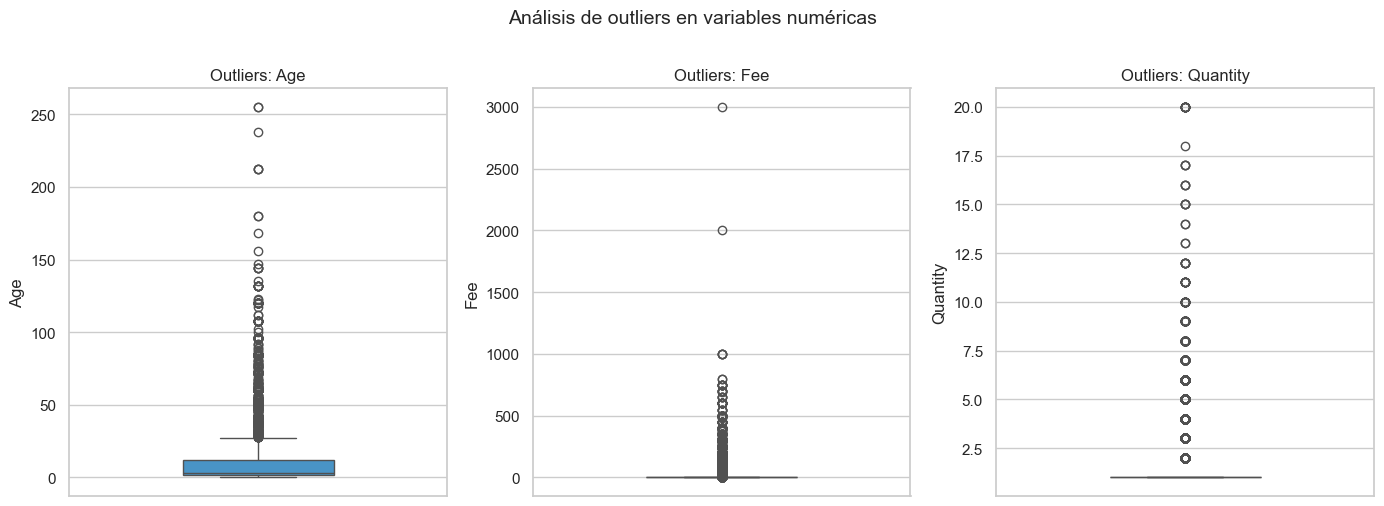

In [95]:
# Boxplots de outliers: Age, Fee, Quantity 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, ['Age', 'Fee', 'Quantity']):
    sns.boxplot(y=train[col], ax=ax, color='#3498db', width=0.4)
    ax.set_title(f'Outliers: {col}', fontsize=12)
    ax.set_ylabel(col)

plt.suptitle('Análisis de outliers en variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretación — Calidad de Datos

- **Age**: presenta valores extremos de hasta **255 meses** (~21 años), lo cual es biológicamente improbable, sobre todo en perros. La mayor parte de la distribución se concentra por debajo de los 60 meses.
- **Fee**: algunos registros tienen fee de hasta **3000**, aunque la mayoría son adopciones gratuitas. Esta variable presenta una distribución muy sesgada hacia la derecha.
- **PhotoAmt**:  Los valores van de 0 a 30+.
- Las columnas con mayor porcentaje de nulos son **Name** y **Description**, lo cual es esperable dado que no todos los anunciantes completan estos campos.

In [96]:
#Al haber valores outliers en los campos Age (muy pocos) se decide imputar aquellos que superan los 180 meses, y asignarle la mediana.
train.loc[train['Age'] > 180, 'Age'] = np.nan
train['Age'] = train['Age'].fillna(train['Age'].median())

---
## Variable Target: AdoptionSpeed

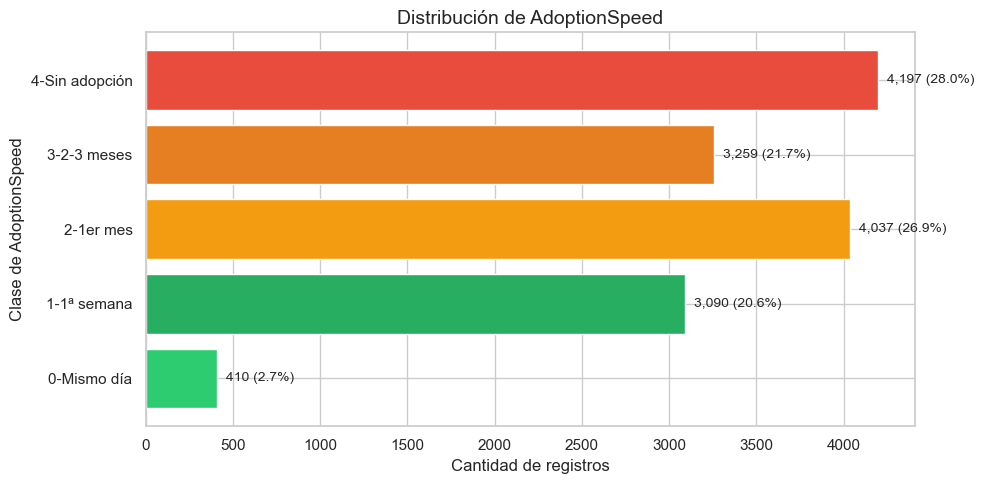

In [97]:
# Barplot horizontal de distribución de AdoptionSpeed 
speed_counts = train['AdoptionSpeed'].value_counts().sort_index()
speed_pct    = (speed_counts / speed_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    [SPEED_LABELS[i] for i in speed_counts.index],
    speed_counts.values,
    color=[SPEED_COLORS[i] for i in speed_counts.index],
    edgecolor='white'
)

# Etiquetas de conteo y porcentaje
for bar, count, pct in zip(bars, speed_counts.values, speed_pct.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f'{count:,} ({pct}%)', va='center', fontsize=10)

ax.set_title('Distribución de AdoptionSpeed', fontsize=14)
ax.set_xlabel('Cantidad de registros')
ax.set_ylabel('Clase de AdoptionSpeed')
plt.tight_layout()
plt.show()

In [98]:
#  Tabla de conteo y porcentaje 
target_table = pd.DataFrame({
    'Clase'      : [SPEED_LABELS[i] for i in speed_counts.index],
    'Conteo'     : speed_counts.values,
    '% del total': speed_pct.values
})
target_table

,Clase,Conteo,% del total
0,0-Mismo día,410,2.7
1,1-1ª semana,3090,20.6
2,2-1er mes,4037,26.9
3,3-2-3 meses,3259,21.7
4,4-Sin adopción,4197,28.0


### Interpretación — AdoptionSpeed

El target presenta una distribución no uniforme entre clases, con cierta concentración en los extremos:

La clase 4 (“Sin adopción”) es la más frecuente (~28%).
La clase 0 (“Mismo día”) es la menos frecuente (~2.7%), lo que refleja que las adopciones inmediatas son poco comunes.
Las clases intermedias (1, 2, 3) presentan una distribución relativamente más equilibrada entre sí.

Si bien existe una leve asimetría en la distribución, no se considera un desbalance severo de clases, ya que no hay una clase dominante extrema (por ejemplo >50%). Por lo tanto, no se aplicarán técnicas específicas de balanceo (como oversampling) en esta etapa.

---
## Tipo de Animal: Perros vs Gatos

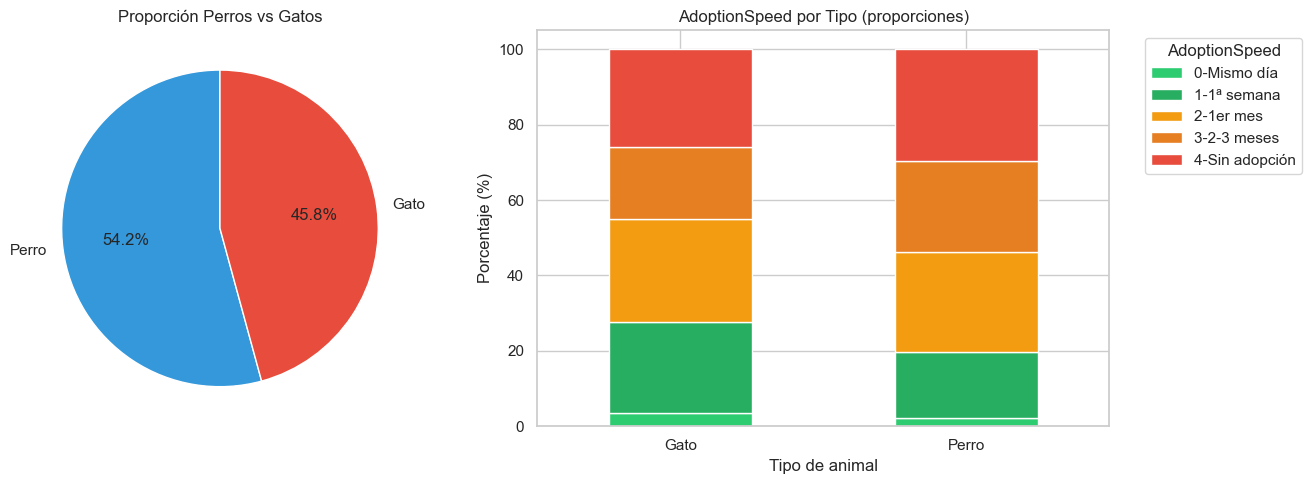

In [99]:
# Pie chart y barplot apilado normalizado 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
type_counts = train['Type_name'].value_counts()
axes[0].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c'],
    startangle=90
)
axes[0].set_title('Proporción Perros vs Gatos', fontsize=12)

# Barplot apilado normalizado: AdoptionSpeed por Type
cross = pd.crosstab(train['Type_name'], train['AdoptionSpeed'], normalize='index') * 100
cross.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=SPEED_PALETTE,
    edgecolor='white'
)
axes[1].set_title('AdoptionSpeed por Tipo (proporciones)', fontsize=12)
axes[1].set_xlabel('Tipo de animal')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend([SPEED_LABELS[i] for i in range(5)], title='AdoptionSpeed', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [100]:
# AdoptionSpeed promedio por tipo
print('AdoptionSpeed promedio por tipo de animal:')
print(train.groupby('Type_name')['AdoptionSpeed'].mean().round(3))

AdoptionSpeed promedio por tipo de animal:
Type_name
Gato     2.400
Perro    2.615
Name: AdoptionSpeed, dtype: float64


### Interpretación — Perros vs Gatos

- Los **perros son ligeramente más frecuentes** que los gatos en el dataset.
- En cuanto a la velocidad de adopción, los **gatos tienden a ser adoptados algo más rápido** en promedio que los perros (AdoptionSpeed promedio: Gato = 2.400 vs Perro = 2.615). Un valor **menor** de AdoptionSpeed indica adopción más rápida.
- La diferencia es pequeña y ambos tipos presentan una distribución similar en las clases intermedias.

---
## Demografía: Edad, Género, Raza

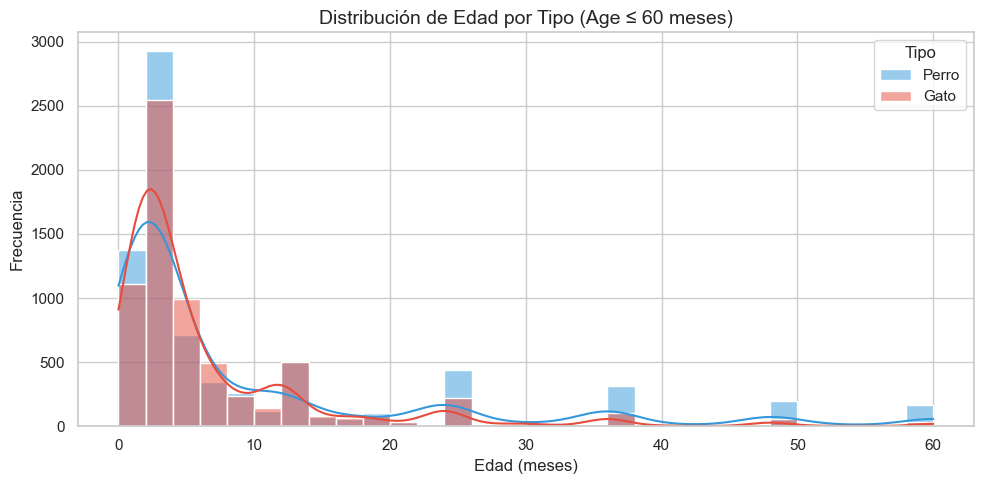

* Se excluyen 386 registros con Age > 60 meses para mejor visualización.


In [101]:
# ── Histograma de Age por Type con KDE overlay ─────────────────────────
df_age = train[train['Age'] <= 60].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for tipo, color in [('Perro', '#3498db'), ('Gato', '#e74c3c')]:
    data = df_age.loc[df_age['Type_name'] == tipo, 'Age']
    sns.histplot(data, bins=30, kde=True, ax=ax, color=color, alpha=0.5, label=tipo)

ax.set_title('Distribución de Edad por Tipo (Age ≤ 60 meses)', fontsize=14)
ax.set_xlabel('Edad (meses)')
ax.set_ylabel('Frecuencia')
ax.legend(title='Tipo')
plt.tight_layout()
plt.show()
print(f'* Se excluyen {(train["Age"] > 60).sum()} registros con Age > 60 meses para mejor visualización.')

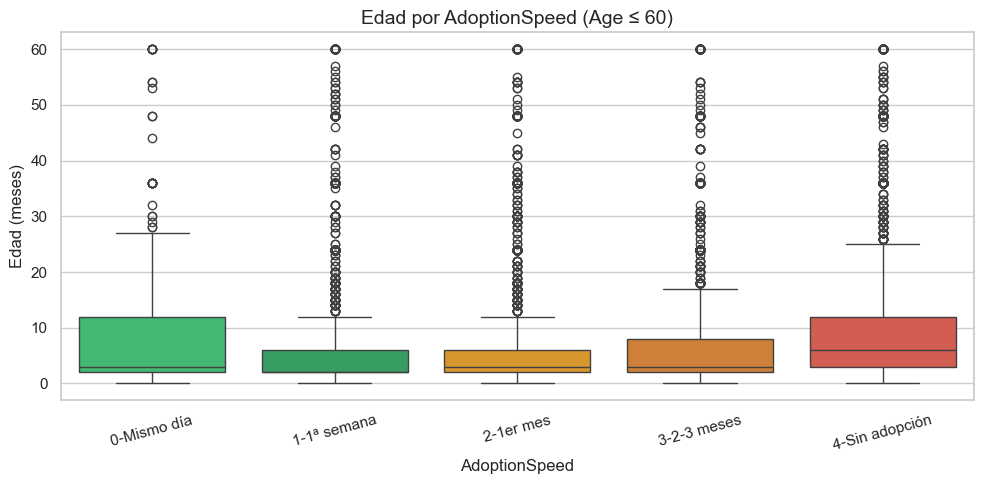

In [102]:
# Boxplot de Age por AdoptionSpeed 
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=train[train['Age'] <= 60],
    x='AdoptionSpeed',
    y='Age',
    palette=SPEED_PALETTE,
    ax=ax
)
ax.set_title('Edad por AdoptionSpeed (Age ≤ 60)', fontsize=14)
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Edad (meses)')
ax.set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15)
plt.tight_layout()
plt.show()

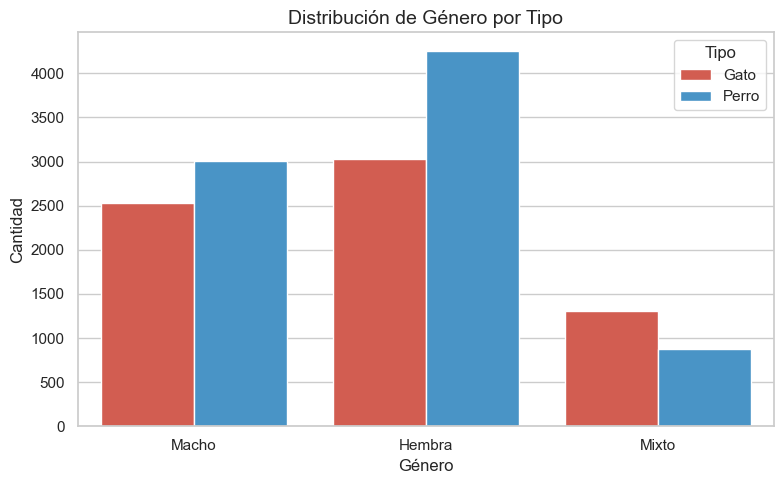

In [103]:
# Countplot de Gender por Type 
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=train,
    x='Gender_name',
    hue='Type_name',
    palette={'Perro': '#3498db', 'Gato': '#e74c3c'},
    ax=ax
)
ax.set_title('Distribución de Género por Tipo', fontsize=14)
ax.set_xlabel('Género')
ax.set_ylabel('Cantidad')
ax.legend(title='Tipo')
plt.tight_layout()
plt.show()

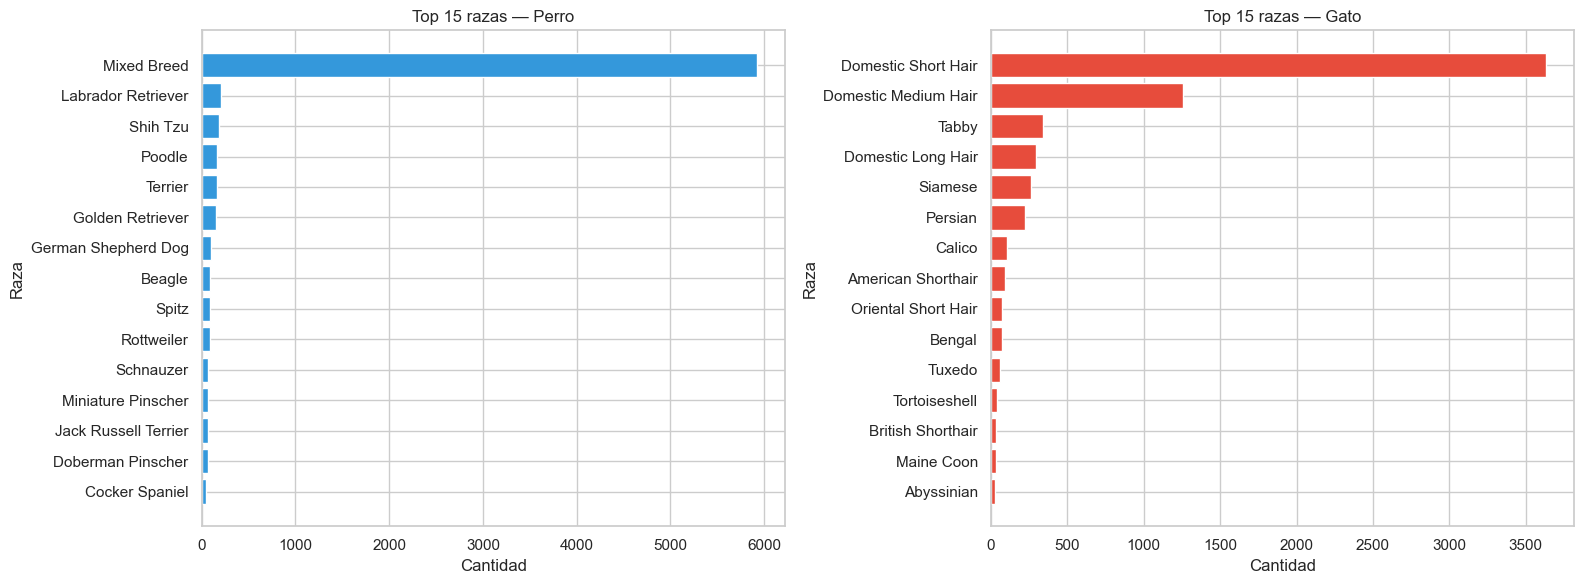

Proporción de mascotas con raza mixta (Breed2 > 0): 28.2%


In [104]:
#  Top 15 razas primarias separadas por Type 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    top_breeds = (
        train[train['Type_name'] == tipo]['Breed1_name']
        .value_counts()
        .head(15)
    )
    ax.barh(top_breeds.index[::-1], top_breeds.values[::-1],
            color='#3498db' if tipo == 'Perro' else '#e74c3c')
    ax.set_title(f'Top 15 razas — {tipo}', fontsize=12)
    ax.set_xlabel('Cantidad')
    ax.set_ylabel('Raza')

plt.tight_layout()
plt.show()

# Proporción con raza mixta
pct_mixta = (train['Breed2'] > 0).mean() * 100
print(f'Proporción de mascotas con raza mixta (Breed2 > 0): {pct_mixta:.1f}%')

### Interpretación — Demografía

- **Edad**: Los cachorros/gatitos jóvenes (0–6 meses) son los más comunes en el dataset. Las mascotas más jóvenes tienden a tener velocidades de adopción más rápidas.
- **Género**: Los machos son ligeramente más frecuentes que las hembras tanto en perros como en gatos. El género mixto aparece en listings grupales.
- **Razas**: La raza más común en perros es el Mestizo, seguido de razas populares locales. En gatos domina el "Domestic Short Hair". Un porcentaje significativo de mascotas tiene raza mixta.

---
## Características Físicas

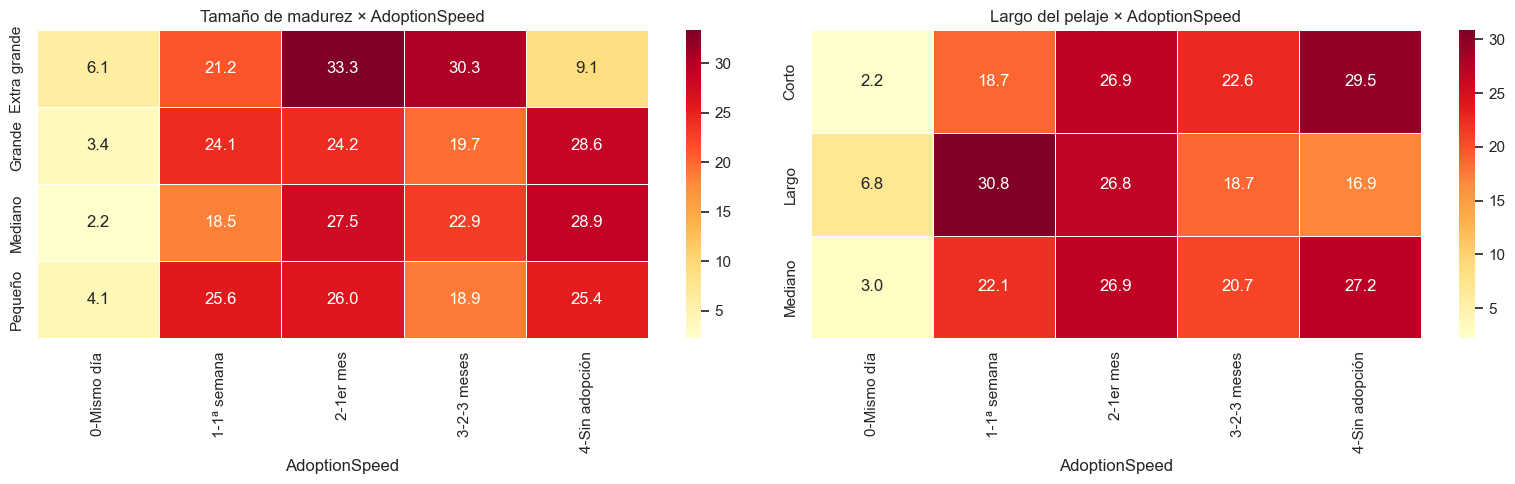

In [105]:
#  MaturitySize como heatmap normalizado 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ['MaturitySize_name', 'FurLength_name'],
    ['Tamaño de madurez × AdoptionSpeed', 'Largo del pelaje × AdoptionSpeed']
):
    pivot = pd.crosstab(train[col], train['AdoptionSpeed'], normalize='index') * 100
    pivot.columns = [SPEED_LABELS[c] for c in pivot.columns]
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('AdoptionSpeed')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

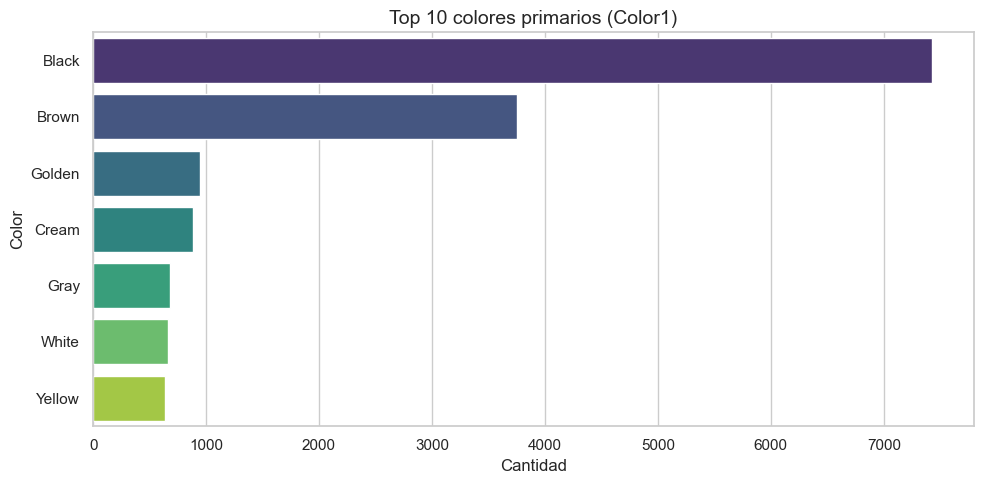

In [106]:
# Top colores (Color1_name) 
top_colors = train['Color1_name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_colors.values, y=top_colors.index, ax=ax, palette='viridis')
ax.set_title('Top 10 colores primarios (Color1)', fontsize=14)
ax.set_xlabel('Cantidad')
ax.set_ylabel('Color')
plt.tight_layout()
plt.show()

### Interpretación — Características Físicas

- **MaturitySize**: Las mascotas de tamaño mediano son las más comunes. No se observan diferencias marcadas en la velocidad de adopción según el tamaño.
- **FurLength**: El pelaje corto es el más frecuente. Las mascotas de pelo largo tienen una ligera tendencia a tardar más en ser adoptadas.
- **Color**: El negro y el marrón/castaño son los colores más frecuentes. Los colores más raros como el dorado o el crema pueden tener ligeras ventajas en adopción.

---
## Sección 6 — Estado de Salud

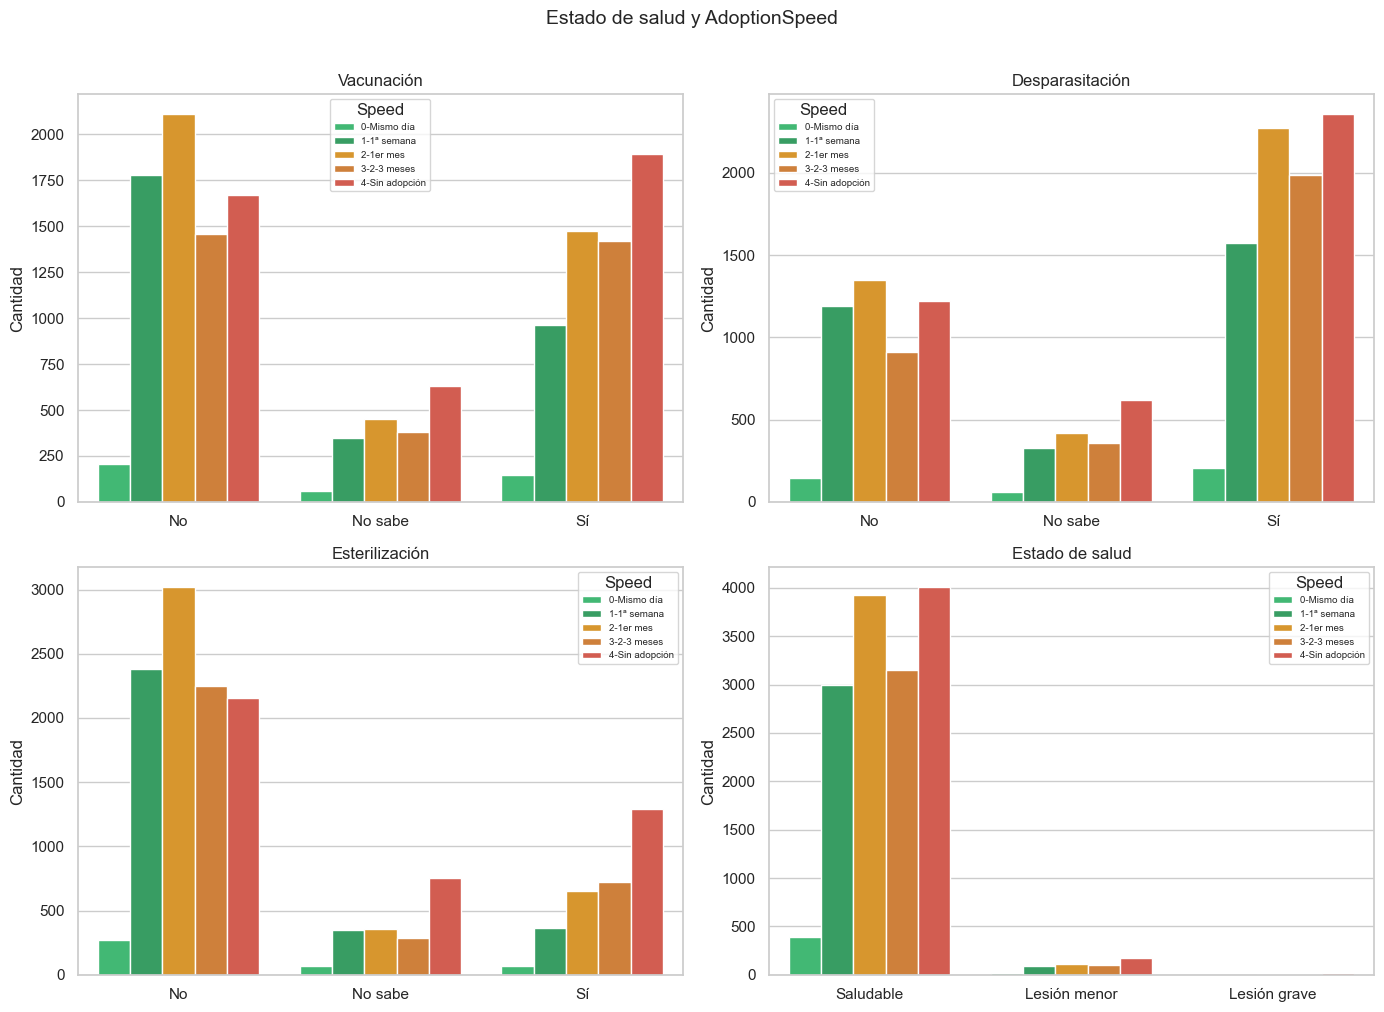

In [107]:
#  Grid de countplots de salud 
health_vars = [
    ('Vaccinated_name', 'Vacunación'),
    ('Dewormed_name',   'Desparasitación'),
    ('Sterilized_name', 'Esterilización'),
    ('Health_name',     'Estado de salud'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, health_vars):
    sns.countplot(
        data=train,
        x=col,
        hue='AdoptionSpeed',
        palette=SPEED_COLORS,
        ax=ax
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad')
    ax.legend(title='Speed', labels=[SPEED_LABELS[i] for i in range(5)], fontsize=7)

plt.suptitle('Estado de salud y AdoptionSpeed', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

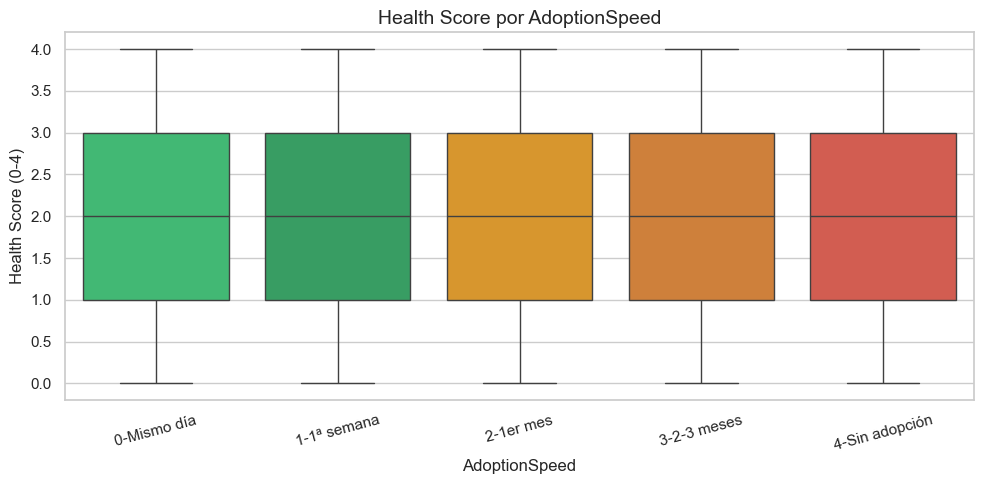

Health Score promedio por AdoptionSpeed:
AdoptionSpeed
0    1.983
1    1.909
2    2.063
3    2.233
4    2.277
Name: health_score, dtype: float64


In [108]:
#  Boxplot de health_score por AdoptionSpeed 
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=train,
    x='AdoptionSpeed',
    y='health_score',
    palette=SPEED_PALETTE,
    ax=ax
)
ax.set_title('Health Score por AdoptionSpeed', fontsize=14)
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Health Score (0-4)')
ax.set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15)
plt.tight_layout()
plt.show()

print('Health Score promedio por AdoptionSpeed:')
print(train.groupby('AdoptionSpeed')['health_score'].mean().round(3))

### Interpretación — Estado de Salud

- La mayoría de las mascotas están **vacunadas y desparasitadas**, pero la **esterilización** es menos común.
- El `health_score` promedio no muestra grandes diferencias entre clases de AdoptionSpeed, lo que sugiere que el estado de salud documentado no es el factor determinante principal para la velocidad de adopción.
- Sin embargo, las mascotas con **score 0** (ningún indicador positivo) tienden a concentrarse más en la clase 4 ("Sin adopción").

---
## Media: Fotos y Videos

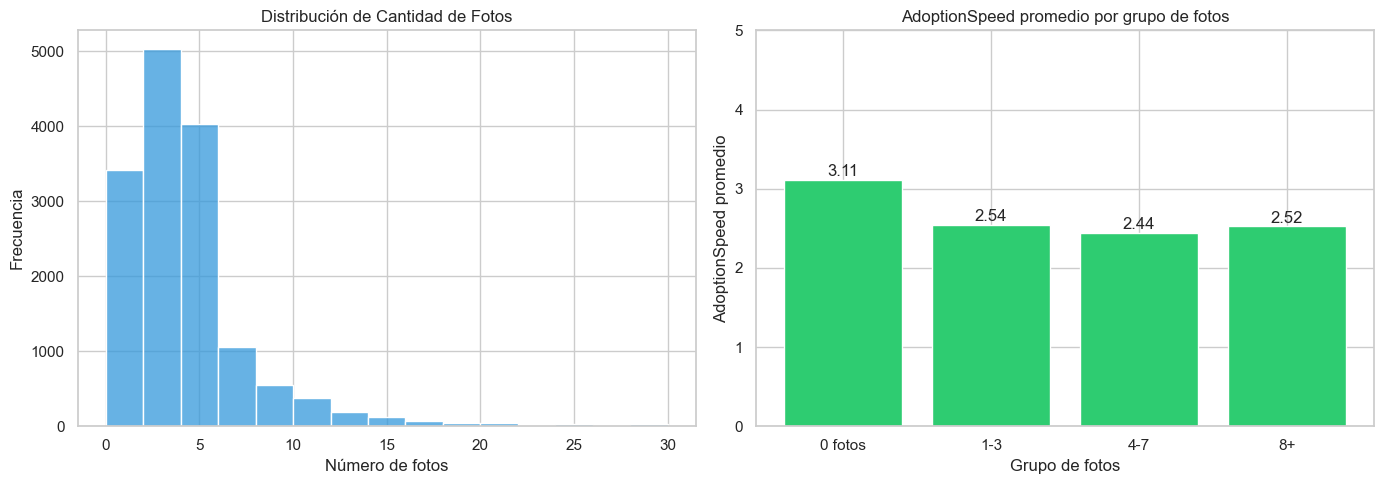

In [109]:
# Histograma de PhotoAmt 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['PhotoAmt'], bins=15, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Distribución de Cantidad de Fotos', fontsize=12)
axes[0].set_xlabel('Número de fotos')
axes[0].set_ylabel('Frecuencia')

# Barplot de AdoptionSpeed promedio por photo_group
photo_order = ['0 fotos', '1-3', '4-7', '8+']
photo_speed = train.groupby('photo_group')['AdoptionSpeed'].mean().reindex(photo_order)
axes[1].bar(photo_speed.index, photo_speed.values, color='#2ecc71', edgecolor='white')
axes[1].set_title('AdoptionSpeed promedio por grupo de fotos', fontsize=12)
axes[1].set_xlabel('Grupo de fotos')
axes[1].set_ylabel('AdoptionSpeed promedio')
axes[1].set_ylim(0, 5)
for i, v in enumerate(photo_speed.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

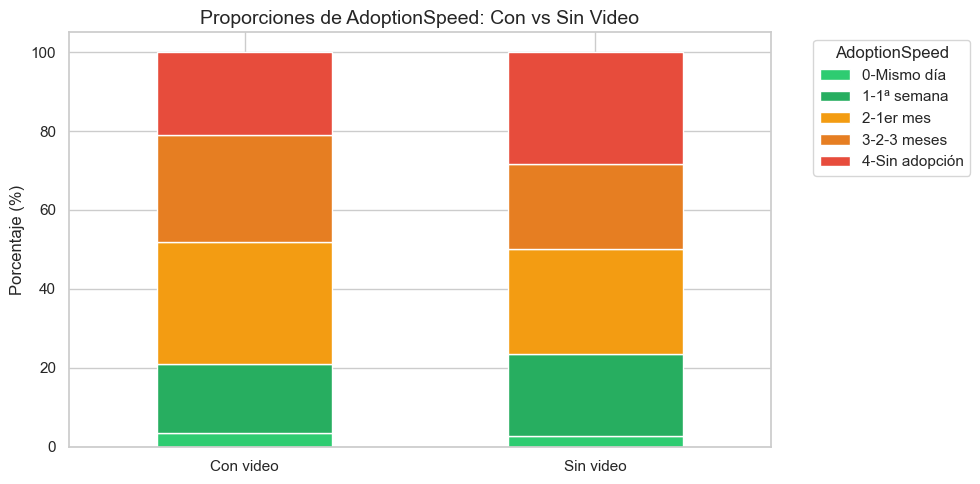

In [110]:
# Barplot VideoAmt vs AdoptionSpeed (proporciones) 
train['tiene_video'] = (train['VideoAmt'] > 0).map({True: 'Con video', False: 'Sin video'})

video_cross = pd.crosstab(train['tiene_video'], train['AdoptionSpeed'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 5))
video_cross.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=SPEED_PALETTE,
    edgecolor='white'
)
ax.set_title('Proporciones de AdoptionSpeed: Con vs Sin Video', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Porcentaje (%)')
ax.legend([SPEED_LABELS[i] for i in range(5)], title='AdoptionSpeed', bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### Interpretación — Fotos y Videos

- Las mascotas **sin fotos** tienen el mayor AdoptionSpeed promedio (más lento), lo que sugiere que incluir imágenes mejora las chances de adopción rápida.
- Existe un punto de rendimiento decreciente: de 1-3 a 4-7 fotos hay mejora, pero más de 8 fotos no necesariamente implica adopción más rápida.
- Los casos **con video** son muy pocos, por lo que no es posible sacar conclusiones sólidas, pero muestran una ligera tendencia positiva.

---
## Sección 8 — Fee (Costo de Adopción)

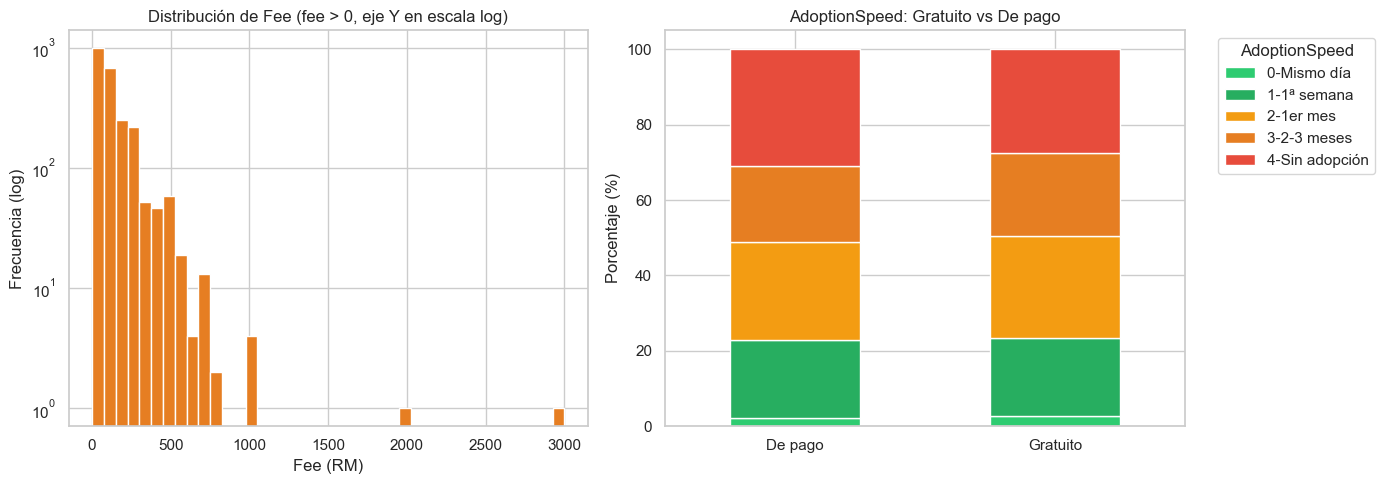

In [111]:
# Distribución del fee en escala log 
fee_pos = train[train['Fee'] > 0]['Fee']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con log scale
axes[0].hist(fee_pos, bins=40, color='#e67e22', edgecolor='white', log=True)
axes[0].set_title('Distribución de Fee (fee > 0, eje Y en escala log)', fontsize=12)
axes[0].set_xlabel('Fee (RM)')
axes[0].set_ylabel('Frecuencia (log)')

# Gratuito vs pago por AdoptionSpeed
train['fee_tipo'] = (train['Fee'] > 0).map({True: 'De pago', False: 'Gratuito'})
fee_cross = pd.crosstab(train['fee_tipo'], train['AdoptionSpeed'], normalize='index') * 100
fee_cross.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=SPEED_PALETTE,
    edgecolor='white'
)
axes[1].set_title('AdoptionSpeed: Gratuito vs De pago', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend([SPEED_LABELS[i] for i in range(5)], title='AdoptionSpeed', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

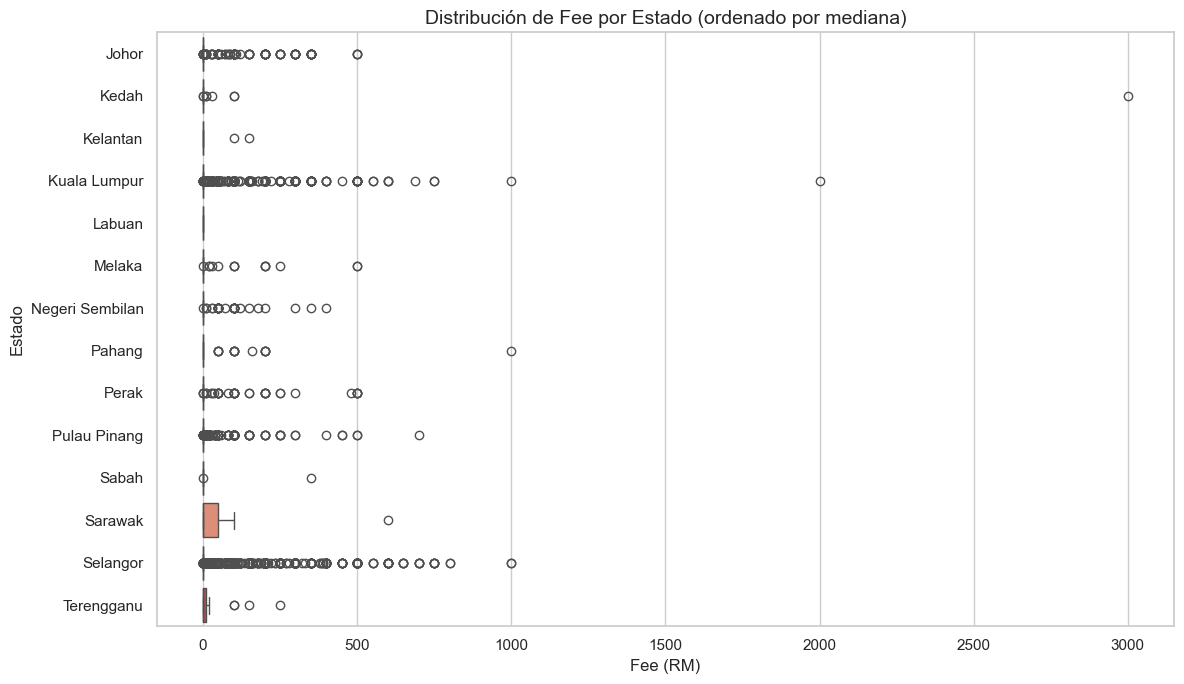

In [112]:
#  Boxplot de Fee por State_name 
state_fee = train.groupby('State_name')['Fee'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    data=train,
    y='State_name',
    x='Fee',
    order=state_fee.index,
    palette='coolwarm',
    ax=ax
)
ax.set_title('Distribución de Fee por Estado (ordenado por mediana)', fontsize=14)
ax.set_xlabel('Fee (RM)')
ax.set_ylabel('Estado')
plt.tight_layout()
plt.show()

### Interpretación — Fee

- La gran mayoría son **gratuitos** (fee = 0).
- Los **pagos** tienden a tener una ligera mayor proporción en la clase 4 ("Sin adopción"), lo que sugiere que cobrar por la adopción puede reducir las chances de ser adoptado rápidamente.
- Existe variabilidad regional en el fee: algunos estados tienen medianas más altas que otros.
- Los valores extremos (hasta 3000 ) son outliers que probablemente corresponden a mascotas de raza pura 

---
##  Geografía: Estados de Malasia

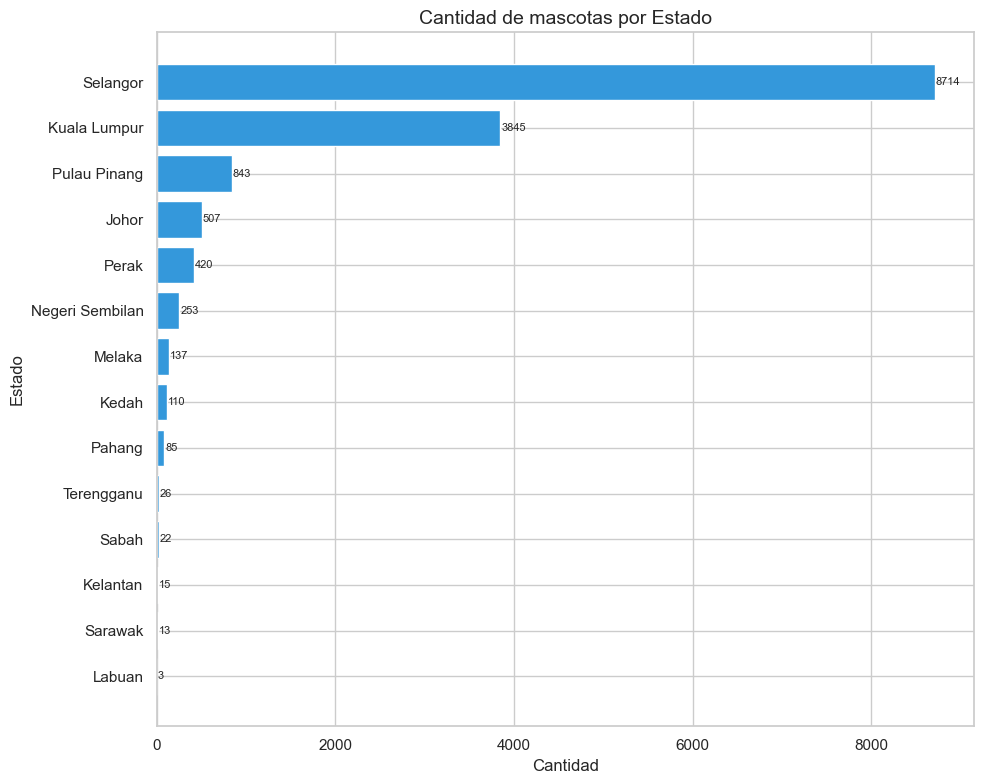

In [113]:
# Barplot horizontal de mascotas por estado
state_counts = train['State_name'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(state_counts.index, state_counts.values, color='#3498db', edgecolor='white')
ax.set_title('Cantidad de mascotas por Estado', fontsize=14)
ax.set_xlabel('Cantidad')
ax.set_ylabel('Estado')
for i, v in enumerate(state_counts.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

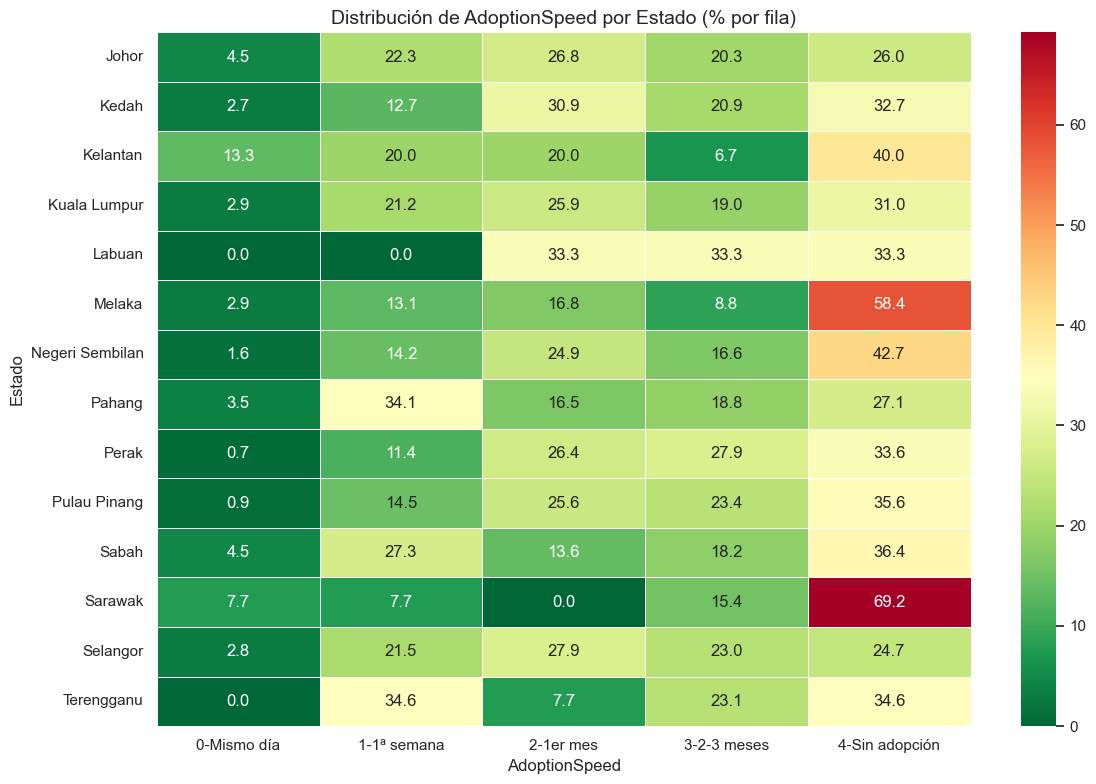

In [114]:
# Heatmap State_name × AdoptionSpeed (proporciones por estado) 
state_speed = pd.crosstab(train['State_name'], train['AdoptionSpeed'], normalize='index') * 100
state_speed.columns = [SPEED_LABELS[c] for c in state_speed.columns]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    state_speed,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Distribución de AdoptionSpeed por Estado (% por fila)', fontsize=14)
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Estado')
plt.tight_layout()
plt.show()

In [115]:
# Tabla de métricas por estado 
state_table = train.groupby('State_name').agg(
    N                = ('PetID', 'count'),
    Fee_promedio     = ('Fee', 'mean'),
    PhotoAmt_prom    = ('PhotoAmt', 'mean'),
    Speed_promedio   = ('AdoptionSpeed', 'mean'),
).round(2).sort_values('N', ascending=False)
state_table

,N,Fee_promedio,PhotoAmt_prom,Speed_promedio
State_name,,,,
Selangor,8714,22.64,4.03,2.45
Kuala Lumpur,3845,19.10,3.93,2.54
Pulau Pinang,843,16.40,3.13,2.78
Johor,507,28.64,3.36,2.41
Perak,420,13.75,3.65,2.82
Negeri Sembilan,253,14.23,3.68,2.85
Melaka,137,16.58,2.72,3.07
Kedah,110,29.56,3.32,2.68
Pahang,85,31.29,4.04,2.32


### Interpretación — Geografía

- **Selangor** y **Kuala Lumpur** concentran la mayor cantidad de perfiles, lo cual refleja la densidad poblacional de la región.
- Los estados con mayor AdoptionSpeed promedio (más lento) pueden indicar menor demanda local de adopciones.
- El fee promedio varía entre estados, reflejando diferencias socioeconómicas regionales.

---
## Nombre de la Mascota

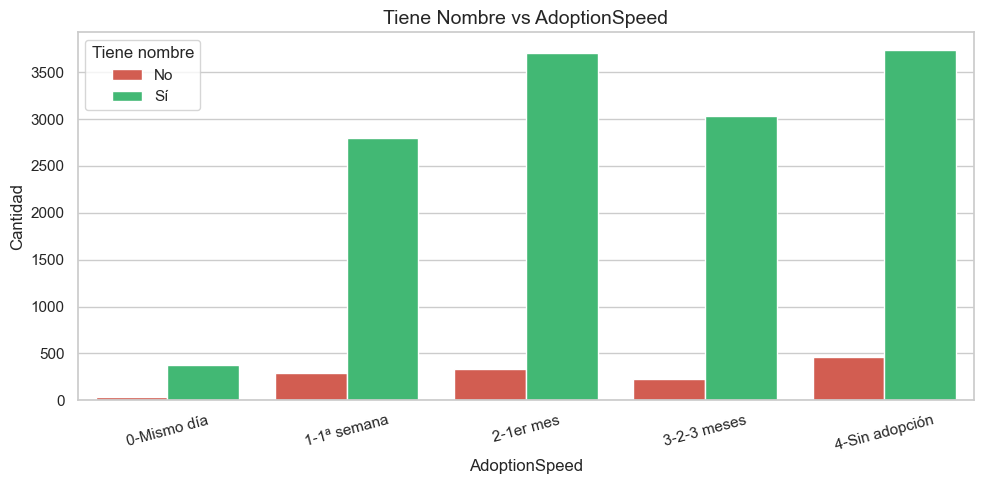

In [116]:
# Countplot Tiene_nombre vs AdoptionSpeed 
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(
    data=train,
    x='AdoptionSpeed',
    hue='Tiene_nombre',
    palette={True: '#2ecc71', False: '#e74c3c'},
    ax=ax
)
ax.set_title('Tiene Nombre vs AdoptionSpeed', fontsize=14)
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Cantidad')
ax.set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15)
ax.legend(title='Tiene nombre', labels=['No', 'Sí'])
plt.tight_layout()
plt.show()

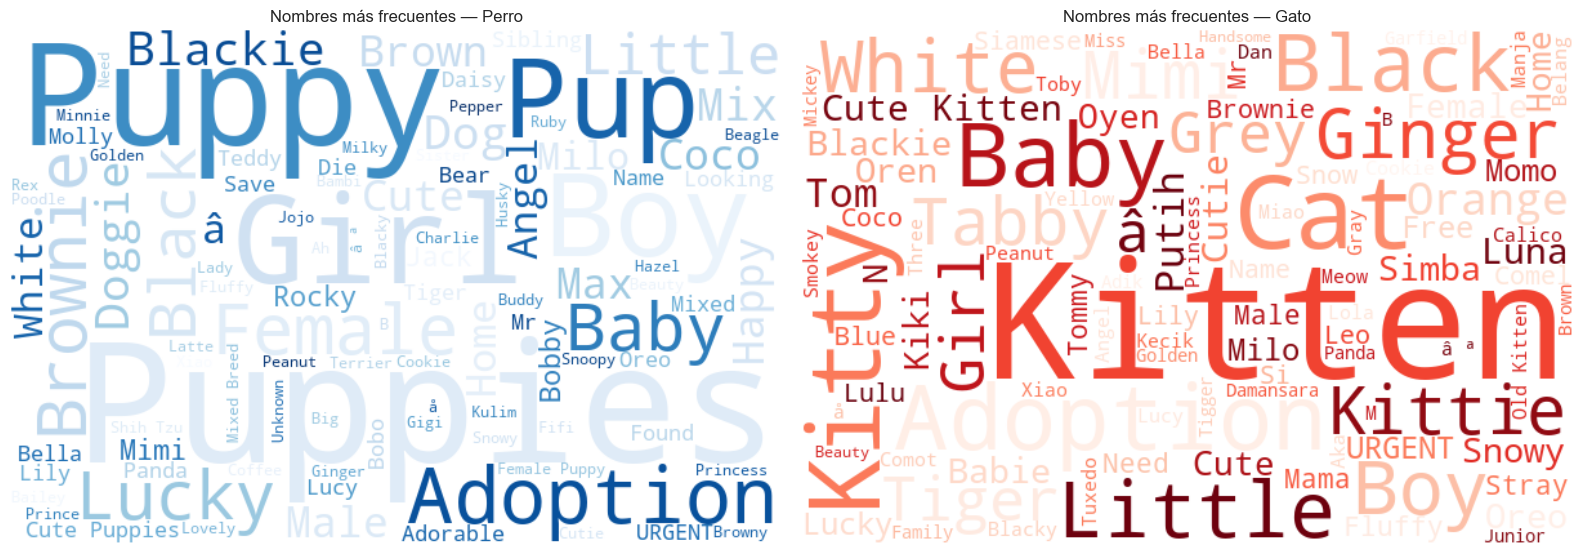

In [117]:
#  WordCloud de nombres (perros y gatos) 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tipo, color in zip(axes, ['Perro', 'Gato'], ['Blues', 'Reds']):
    names_corpus = ' '.join(
        train[
            (train['Type_name'] == tipo) &
            (train['Tiene_nombre'])
        ]['Name'].dropna().tolist()
    )
    if names_corpus.strip():
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=color,
            max_words=100
        ).generate(names_corpus)
        ax.imshow(wc, interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center')
    ax.axis('off')
    ax.set_title(f'Nombres más frecuentes — {tipo}', fontsize=12)

plt.tight_layout()
plt.show()

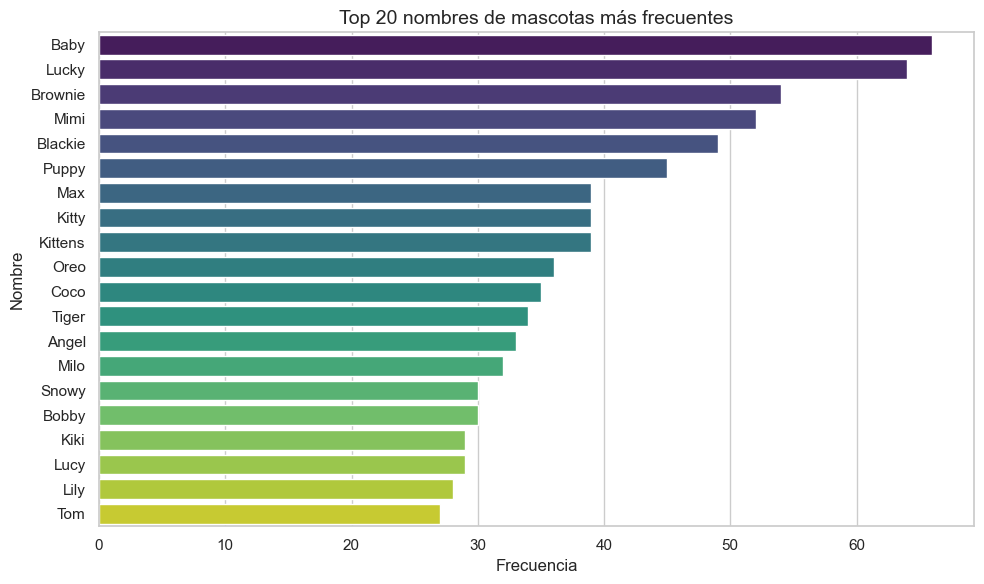

In [118]:
#  Top 20 nombres más frecuentes 
top_names = (
    train[train['Tiene_nombre']]['Name']
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_names.values, y=top_names.index, ax=ax, palette='viridis')
ax.set_title('Top 20 nombres de mascotas más frecuentes', fontsize=14)
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Nombre')
plt.tight_layout()
plt.show()

### Interpretación — Nombre de la Mascota

- Las mascotas **con nombre** tienen una distribución de AdoptionSpeed ligeramente más favorable (más rápida) que las anónimas.
- La presencia de un nombre puede actuar como proxy de mayor cuidado y personalización del anuncio.

---
##  Descripción y Sentimiento

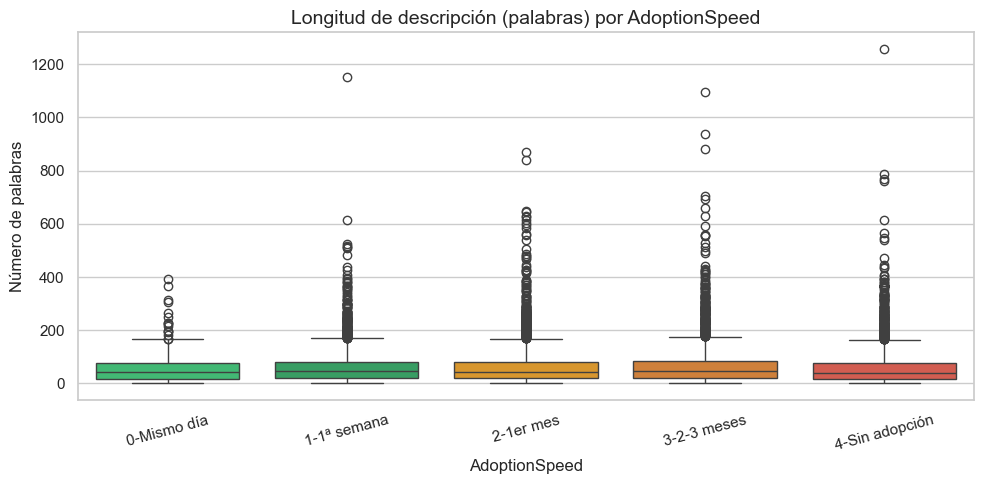

In [119]:
#  Boxplot de Desc_len_words por AdoptionSpeed 
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=train,
    x='AdoptionSpeed',
    y='Desc_len_words',
    palette=SPEED_PALETTE,
    ax=ax
)
ax.set_title('Longitud de descripción (palabras) por AdoptionSpeed', fontsize=14)
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Número de palabras')
ax.set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15)
plt.tight_layout()
plt.show()

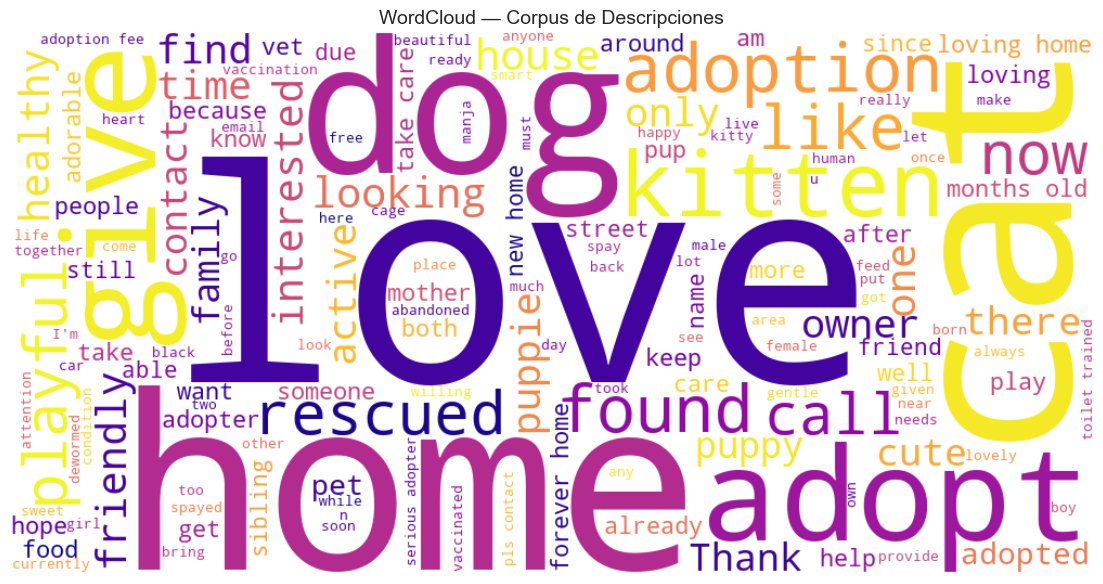

In [120]:
# ── WordCloud del corpus de descripciones ─────────────────────────────
# Stopwords básicas en inglés
basic_stopwords = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','being','have','has','had','do',
    'does','did','will','would','could','should','may','might','shall',
    'it','its','he','she','they','we','you','i','me','him','her','them',
    'us','my','your','his','our','their','this','that','these','those',
    'very','also','not','no','so','if','by','from','as','up','out','about',
    'into','than','then','when','where','who','which','what','how','all',
    'can','please','need','good','will','just'
}

corpus = ' '.join(train['Description'].dropna().tolist())

fig, ax = plt.subplots(figsize=(14, 6))
wc = WordCloud(
    width=1000, height=500,
    background_color='white',
    stopwords=basic_stopwords,
    max_words=150,
    colormap='plasma'
).generate(corpus)

ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — Corpus de Descripciones', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretación — Descripción 

- Las mascotas con **descripciones más largas** tienden a distribuirse de manera más uniforme entre clases, mientras que los perfiles sin descripción (0 palabras) se concentran en clases de adopción lenta.
- El corpus de descripciones muestra palabras como "healthy", "friendly", "vaccinated", "looking", "home", lo que indica un lenguaje orientado a resaltar las virtudes de la mascota.

---
## Perfiles Grupales

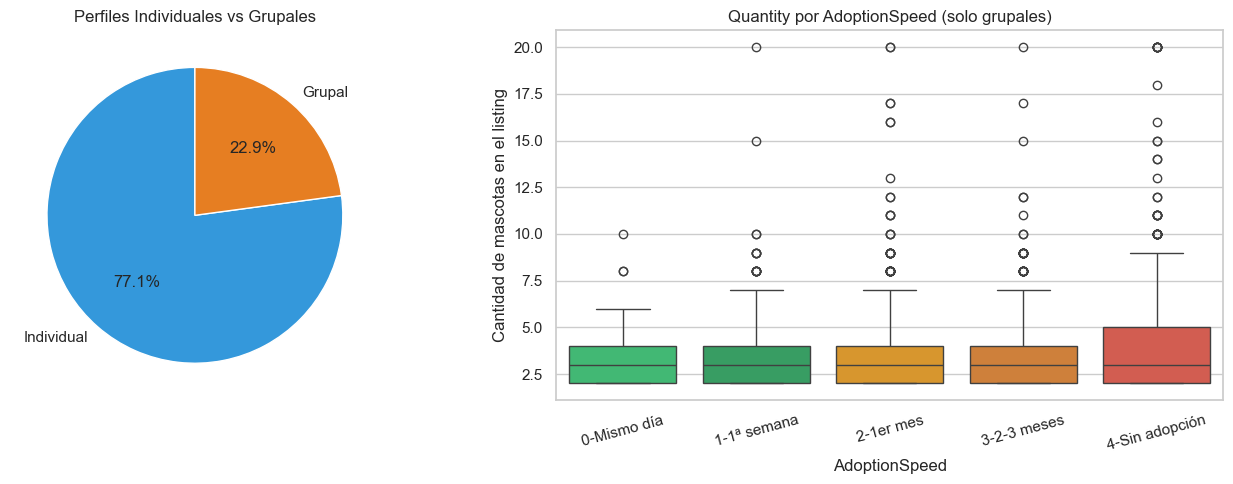

In [121]:
# Pie chart individual vs grupal 
train['listing_tipo'] = (train['Quantity'] == 1).map({True: 'Individual', False: 'Grupal'})
lt_counts = train['listing_tipo'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    lt_counts.values,
    labels=lt_counts.index,
    autopct='%1.1f%%',
    colors=['#3498db', '#e67e22'],
    startangle=90
)
axes[0].set_title('Perfiles Individuales vs Grupales', fontsize=12)

# Boxplot Quantity por AdoptionSpeed (solo grupal)
df_grupal = train[train['Quantity'] > 1]
sns.boxplot(
    data=df_grupal,
    x='AdoptionSpeed',
    y='Quantity',
    palette=SPEED_PALETTE,
    ax=axes[1]
)
axes[1].set_title('Quantity por AdoptionSpeed (solo grupales)', fontsize=12)
axes[1].set_xlabel('AdoptionSpeed')
axes[1].set_ylabel('Cantidad de mascotas en el listing')
axes[1].set_xticklabels([SPEED_LABELS[i] for i in range(5)], rotation=15)

plt.tight_layout()
plt.show()

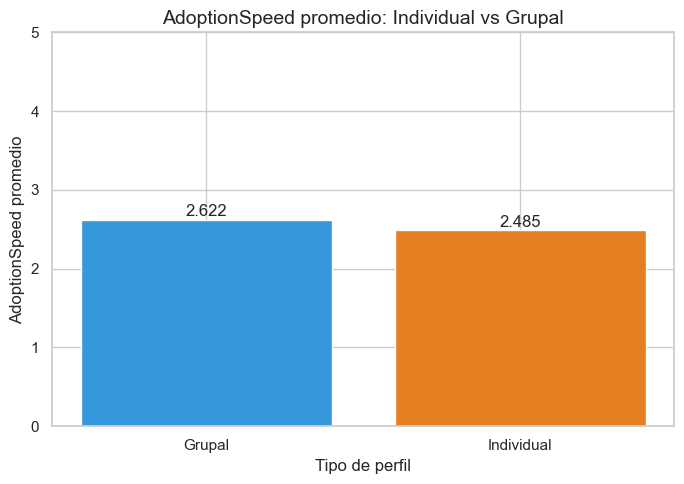

In [122]:
#  AdoptionSpeed promedio: individual vs grupal 
speed_by_type = train.groupby('listing_tipo')['AdoptionSpeed'].mean().round(3)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(speed_by_type.index, speed_by_type.values,
              color=['#3498db', '#e67e22'], edgecolor='white')
ax.set_title('AdoptionSpeed promedio: Individual vs Grupal', fontsize=14)
ax.set_xlabel('Tipo de perfil')
ax.set_ylabel('AdoptionSpeed promedio')
ax.set_ylim(0, 5)
for bar, v in zip(bars, speed_by_type.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

### Interpretación — Perfiles Grupales

- La mayoría de los perfiles son **individuales** (Quantity == 1).
- Los perfiles grupales (camadas) tienden a tener un AdoptionSpeed promedio ligeramente diferente, lo que podría relacionarse con la mayor dificultad de encontrar adoptantes dispuestos a llevarse múltiples mascotas.
- La variable `Quantity` tiene outliers significativos, con algunos perfiles de hasta 20+ mascotas.

---
## Análisis Multivariado

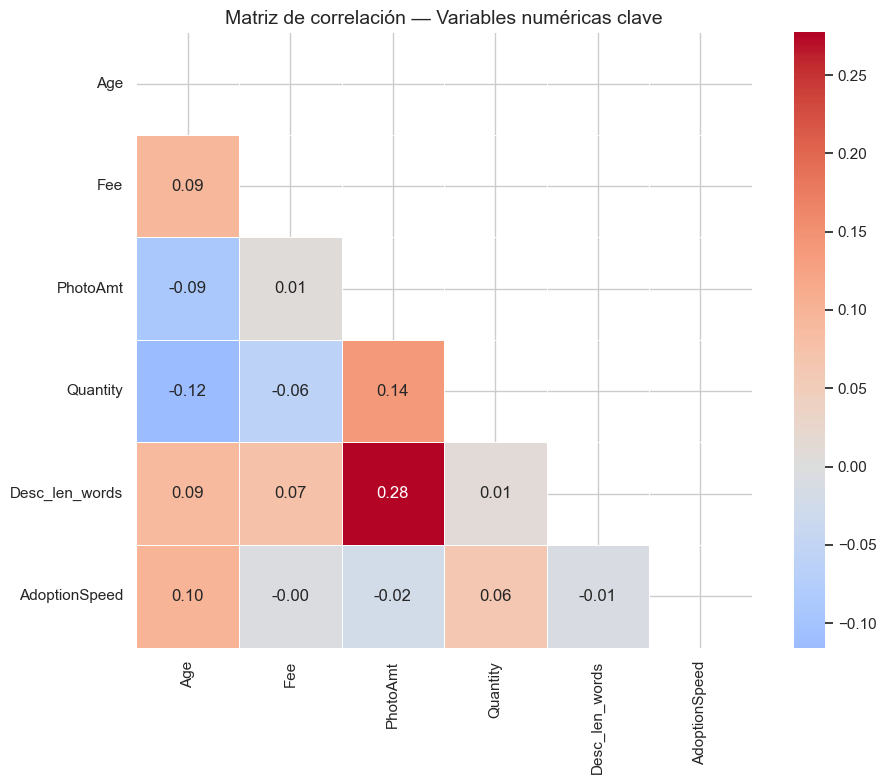

In [123]:
#  Matriz de correlación 
numeric_vars = ['Age', 'Fee', 'PhotoAmt', 'Quantity', 'Desc_len_words',
                 'AdoptionSpeed']

corr_matrix = train[numeric_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    ax=ax,
    linewidths=0.5,
    square=True
)
ax.set_title('Matriz de correlación — Variables numéricas clave', fontsize=14)
plt.tight_layout()
plt.show()

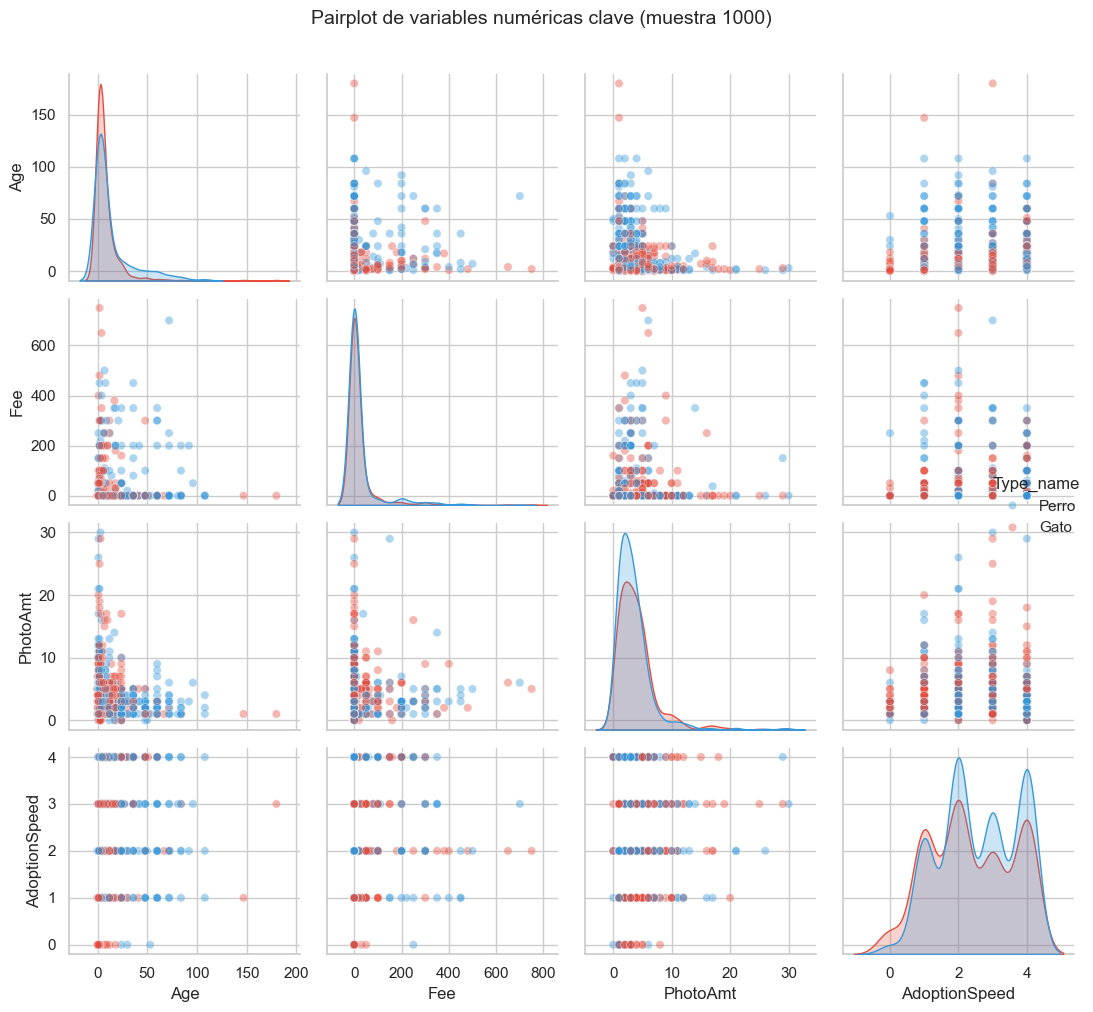

In [124]:
#  Pairplot: Age, Fee, PhotoAmt, AdoptionSpeed coloreado por Type 
sample_pp = train[['Age', 'Fee', 'PhotoAmt', 'AdoptionSpeed', 'Type_name']].dropna().sample(1000, random_state=42)

pp = sns.pairplot(
    sample_pp,
    hue='Type_name',
    palette={'Perro': '#3498db', 'Gato': '#e74c3c'},
    plot_kws={'alpha': 0.4},
    diag_kind='kde'
)
pp.fig.suptitle('Pairplot de variables numéricas clave (muestra 1000)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [129]:
from scipy.stats import kruskal

# Conversiones necesarias
train['Tiene_nombre_int'] = train['Tiene_nombre'].astype(int)
train['fee_binario']      = (train['Fee'] > 0).astype(int)

kw_vars = {
    'Age'                  : 'Age',
    'Fee (valor numérico)' : 'Fee',
    'Fee binario (pago=1)' : 'fee_binario',
    'PhotoAmt'             : 'PhotoAmt',
    'Quantity'             : 'Quantity',
    'Desc_len_words'       : 'Desc_len_words',
    'health_score'         : 'health_score',
    'Tiene_nombre'         : 'Tiene_nombre_int',
    'Breed1 (raza)'        : 'Breed1',
    'Color1 (color)'       : 'Color1',
    'Vaccinated'           : 'Vaccinated',
    'Dewormed'             : 'Dewormed',
    'Sterilized'           : 'Sterilized',
    'Health'               : 'Health',
    'Gender'               : 'Gender',
    'Type'                 : 'Type',
    'MaturitySize'         : 'MaturitySize',
    'FurLength'            : 'FurLength',
}

groups = [train[train['AdoptionSpeed'] == s] for s in sorted(train['AdoptionSpeed'].unique())]

results = []
for label, col in kw_vars.items():
    samples = [g[col].dropna().values for g in groups]
    stat, pval = kruskal(*samples)
    results.append({
        'Variable'              : label,
        'Estadístico H'         : round(stat, 2),
        'p-value'               : pval,
        'Significativa (p<0.05)': 'Sí' if pval < 0.05 else 'No'
    })

kw_df = pd.DataFrame(results).sort_values('Estadístico H', ascending=False).reset_index(drop=True)
kw_df['p-value'] = kw_df['p-value'].apply(lambda x: f'{x:.2e}')
print('Test de Kruskal-Wallis — Asociación con AdoptionSpeed')
kw_df

Test de Kruskal-Wallis — Asociación con AdoptionSpeed


,Variable,Estadístico H,p-value,Significativa (p<0.05)
0,Age,819.11,5.56e-176,Sí
1,Breed1 (raza),371.27,4.47e-79,Sí
2,PhotoAmt,305.74,6.25e-65,Sí
3,health_score,207.72,8.22e-44,Sí
4,Type,162.16,5.04e-34,Sí
5,Sterilized,136.15,1.88e-28,Sí
6,FurLength,114.91,6.51e-24,Sí
7,Vaccinated,92.38,4.10e-19,Sí
8,Gender,58.95,4.82e-12,Sí
9,Dewormed,56.95,1.27e-11,Sí


### Interpretación — Análisis Multivariado

- Las correlaciones con **AdoptionSpeed** son en general bajas, lo que confirma que el problema es complejo y multifactorial. Ninguna variable por sí sola explica bien la velocidad de adopción.
- La correlación más notable con AdoptionSpeed es **Age** (positiva: mascotas más viejas tardan más en adoptarse) y **PhotoAmt** (negativa: más fotos, adopción más rápida).
- El pairplot muestra que perros y gatos tienen distribuciones similares pero con algunas diferencias notables en Age y Fee.

#### Test de Kruskal-Wallis

A diferencia de la correlación de Pearson (que solo detecta relaciones lineales), el test de **Kruskal-Wallis** evalúa si la distribución de cada variable numérica difiere significativamente entre los 5 grupos de `AdoptionSpeed`, sin asumir normalidad ni linealidad.

- **H0:** la distribución de la variable es igual en todos los grupos de AdoptionSpeed
- **Si p-value < 0.05:** se rechaza H0 → hay asociación estadísticamente significativa con el target

Los resultados confirman que **todas las variables testeadas tienen asociación significativa** con `AdoptionSpeed` (p < 0.05), incluso aquellas con correlación lineal baja. 

In [130]:
train.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Tiene_nombre,Desc_len_words,photo_group,health_score,Speed_label,tiene_video,fee_tipo,listing_tipo,Tiene_nombre_int,fee_binario
0,2,Nibble,3.0,299,0,1,1,7,0,1,...,True,69,1-3,1,2-1er mes,Sin video,De pago,Individual,1,1
1,2,No Name Yet,1.0,265,0,1,1,2,0,2,...,False,23,1-3,1,0-Mismo día,Sin video,Gratuito,Individual,0,0
2,1,Brisco,1.0,307,0,1,2,7,0,2,...,True,69,4-7,3,3-2-3 meses,Sin video,Gratuito,Individual,1,0
3,1,Miko,4.0,307,0,2,1,2,0,2,...,True,25,8+,3,2-1er mes,Sin video,De pago,Individual,1,1
4,1,Hunter,1.0,307,0,1,1,0,0,2,...,True,81,1-3,1,2-1er mes,Sin video,Gratuito,Individual,1,0


---
## Síntesis de Hallazgos

### Tabla Resumen de Hallazgos — basada en Test de Kruskal-Wallis

El nivel de impacto se determina a partir del **estadístico H** del test de Kruskal-Wallis: valores más altos indican mayor diferenciación entre grupos de AdoptionSpeed. Todas las variables son estadísticamente significativas (p < 0.05).

| Variable | Hallazgo principal | H  | Impacto |
|---|---|:---:|:---:|
| **Age** | Se observa que mascotas más jóvenes tienden a adoptarse más rápido | 819.11 |  Alto |
| **Breed1** | La raza muestra alta diferenciación entre grupos, posiblemente influida por su alta cardinalidad | 371.27 |  Alto |
| **PhotoAmt** | Se observa una tendencia donde mayor cantidad de fotos se asocia con adopciones más rápidas, con posibles rendimientos decrecientes a partir de cierto punto | 305.74 |  Alto |
| **health_score** | La variable compuesta health_score concentra mayor señal que sus componentes individuales, lo que sugiere que la condición general de salud es más relevante que atributos específicos aislados. | 207.72 |  Moderado-Alto |
| **Type** | Gatos se adoptan ligeramente más rápido que perros en promedio | 162.16 |  Moderado |
| **Sterilized** | Mascotas esterilizadas presentan mejor distribución de AdoptionSpeed | 136.15 |  Moderado |
| **FurLength** | Pelaje corto tiende a asociarse con adopciones más rápidas | 114.91 |  Moderado |
| **Vaccinated** | Mascotas vacunadas tienen ventaja en velocidad de adopción | 92.38 |  Moderado |
| **Gender** | Existen diferencias de distribución entre géneros, aunque no son extremas | 58.95 |  Bajo-Moderado |
| **Dewormed** | Desparasitación asociada a adopciones algo más rápidas | 56.95 |  Bajo-Moderado |
| **Quantity** | Perfiles grupales (camadas) tienden a adoptarse algo más lento | 55.68 |  Bajo-Moderado |
| **MaturitySize** | Tamaño de madurez presenta diferencias distribucionales menores | 49.03 |  Bajo-Moderado |
| **Desc_len_words** | Descripciones más elaboradas se asocian con mejor performance | 40.62 |  Bajo-Moderado |
| **Tiene_nombre** | Mascotas con nombre registran ligera ventaja en adopción | 39.45 | Bajo-Moderado |
| **Color1** | El color primario tiene poca influencia en la velocidad de adopción | 21.37 |  Bajo |
| **Health** | Estado de salud declarado tiene impacto limitado | 20.82 |  Bajo |
| **Fee** | La diferencia entre publicaciones gratuitas y pagas muestra una señal débil, mientras que el valor numérico del fee prácticamente no presenta asociación con el target | 14.61 |  Bajo |


---

### Conclusión

El análisis exploratorio del dataset **PetFinder Adoption Prediction** revela que la velocidad de adopción de mascotas en Malasia es un fenómeno **multifactorial** con baja correlación lineal entre las variables individuales y el target, lo que indica la presencia de relaciones no lineales y posibles interacciones entre variables 

En general, las variables con mayor capacidad de diferenciación están relacionadas con características intrínsecas de la mascota (edad, raza, estado de salud) y con la calidad de la publicación (cantidad de fotos). En contraste, variables como el costo de adopción o atributos estéticos presentan menor influencia en la velocidad de adopción.

En cuanto al balance del target **AdoptionSpeed**: si bien la clase 4 ("Sin adopción") es la más frecuente (~28%), no hay una clase dominante extrema (>50%), por lo que no se aplicarán técnicas de balanceo en esta etapa.
